# Clinical Severity Correlation — HbO Activation vs Anxiety Scores (GNG)

**Goal:** Test whether prefrontal HbO STD amplitude (per channel, on the GNG task) correlates with clinical anxiety severity in the GAD subjects.

**Cohort (GNG, GAD only):** n=29 (`data/processed-new-mc/GNG/anxiety/`).

**Severity measures:**
- **STAI-T** (Trait Anxiety Inventory, Trait scale) — all 29 GAD subjects.
- **HAMA** (Hamilton Anxiety Rating Scale) — 28 GAD subjects (LA063 not administered, HAMA_sum=0; excluded).

**Method:**
- Spearman rank correlation per channel between HbO STD activation and severity score.
- Benjamini-Hochberg FDR correction (q=0.05) over the 23 channels.
- Topographic visualization, score-distribution histograms, scatter plots for top channels.

> **Note:** This analysis uses **all 29 GAD subjects** (i.e. it is not affected by the
> 11 demographics-missing subjects, since they do have HAMA / STAI scores).

## 1. Imports & Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

PROJECT_ROOT      = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..'))
DATA_DIR          = os.path.join(PROJECT_ROOT, 'data', 'processed-new-mc')
TASK              = 'GNG'
GROUND_TRUTH_XLSX = os.path.join(PROJECT_ROOT, 'data', 'subjects_ground_truth.xlsx')
OUT_DIR           = os.path.join(PROJECT_ROOT, 'src', 'notebook', 'statistical-analysis', '04_severity_correlation')
os.makedirs(OUT_DIR, exist_ok=True)
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

CHANNEL_NAMES = [
    'S1_D1','S1_D3','S2_D2','S2_D1','S2_D5','S3_D1','S3_D3','S3_D4','S3_D6',
    'S4_D4','S4_D5','S4_D7','S5_D2','S5_D5','S5_D8','S6_D3','S6_D6',
    'S7_D4','S7_D6','S7_D7','S8_D5','S8_D7','S8_D8',
]
GRID_POS = [(0,2),(1,1),(0,4),(0,3),(1,4),(1,2),(2,1),(2,2),(3,1),
            (2,3),(2,4),(3,4),(1,5),(2,5),(3,6),(3,0),(4,1),
            (3,2),(4,2),(4,3),(3,5),(4,4),(4,5)]
GRID_SHAPE = (5, 7)
N_CH = len(CHANNEL_NAMES)
CH_TO_IDX = {ch: i for i, ch in enumerate(CHANNEL_NAMES)}


PROJECT_ROOT = /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method


## 2. Load Severity Scores (GAD)

In [2]:
GAD_IDS = sorted(os.listdir(os.path.join(DATA_DIR, TASK, 'anxiety')))
print(f'GAD subjects (n={len(GAD_IDS)}): {GAD_IDS}')

gt = pd.read_excel(GROUND_TRUTH_XLSX).set_index('subject_id')
stait_all = np.array([gt.loc[s, 'STAIT_sum'] for s in GAD_IDS], dtype=float)
hama_all  = np.array([gt.loc[s, 'HAMA_sum']  for s in GAD_IDS], dtype=float)

# Exclude LA063 from HAMA (not administered, recorded as 0)
hama_mask = hama_all > 0
gad_hama  = [s for s, m in zip(GAD_IDS, hama_mask) if m]
hama_vals = hama_all[hama_mask]

print()
print(f'STAI-T : n={len(stait_all)}, mean={stait_all.mean():.1f} ± {stait_all.std(ddof=1):.1f}, '
      f'range=[{stait_all.min():.0f}, {stait_all.max():.0f}]')
print(f'HAMA   : n={len(hama_vals)} (LA063 excluded), '
      f'mean={hama_vals.mean():.1f} ± {hama_vals.std(ddof=1):.1f}, '
      f'range=[{hama_vals.min():.0f}, {hama_vals.max():.0f}]')


GAD subjects (n=29): ['AA011', 'AA013', 'AA041', 'AA056', 'AA064', 'AA089', 'AA090', 'AA092', 'AA093', 'AA094', 'AA097', 'AA098', 'AA099', 'EA055', 'EA060', 'EA061', 'EA062', 'LA042', 'LA051', 'LA052', 'LA053', 'LA054', 'LA057', 'LA058', 'LA059', 'LA063', 'LA091', 'LA095', 'LA096']

STAI-T : n=29, mean=54.2 ± 11.6, range=[28, 75]
HAMA   : n=28 (LA063 excluded), mean=20.8 ± 9.1, range=[7, 40]


## 3. Load HbO Activations for GAD Subjects

In [3]:
def load_activation(subject_id):
    path = os.path.join(DATA_DIR, TASK, 'anxiety', subject_id, 'hbo')
    files = sorted(os.listdir(path))
    concat = np.concatenate([np.load(os.path.join(path, f)) for f in files], axis=1)
    return concat.std(axis=1)  # (23,)

act = np.array([load_activation(s) for s in GAD_IDS])  # (29, 23)
print(f'GAD HbO activation shape: {act.shape}, mean={act.mean():.4f}')


GAD HbO activation shape: (29, 23), mean=0.8863


## 4. Spearman Correlations per Channel

In [4]:
def spearman_per_ch(activation, scores_vec):
    r_arr = np.zeros(N_CH); p_arr = np.zeros(N_CH)
    for ch in range(N_CH):
        r, p = stats.spearmanr(activation[:, ch], scores_vec)
        r_arr[ch] = r; p_arr[ch] = p
    _, p_fdr, _, _ = multipletests(p_arr, alpha=0.05, method='fdr_bh')
    return r_arr, p_arr, p_fdr

results = {}
r, p, p_fdr = spearman_per_ch(act, stait_all)
results['STAIT'] = {'r': r, 'p': p, 'p_fdr': p_fdr, 'n': len(stait_all)}

r, p, p_fdr = spearman_per_ch(act[hama_mask], hama_vals)
results['HAMA']  = {'r': r, 'p': p, 'p_fdr': p_fdr, 'n': len(hama_vals)}

print('=== Spearman correlations (HbO STD vs severity, per channel) ===')
for k in ['STAIT', 'HAMA']:
    n_sig = (results[k]['p'] < 0.05).sum()
    n_fdr = (results[k]['p_fdr'] < 0.05).sum()
    print(f'  {k} (n={results[k]["n"]}): channels p<0.05 (uncorrected) = {n_sig}/{N_CH}, q<0.05 (FDR) = {n_fdr}/{N_CH}')

print('\nTop-5 by |r| for each measure:')
for k in ['STAIT', 'HAMA']:
    df = pd.DataFrame({'channel': CHANNEL_NAMES, 'r': results[k]['r'],
                       'p_raw': results[k]['p'], 'p_fdr': results[k]['p_fdr']})
    df['abs_r'] = df['r'].abs()
    print(f'\n--- {k} (n={results[k]["n"]}) ---')
    print(df.sort_values('abs_r', ascending=False).head(5)[['channel','r','p_raw','p_fdr']]
          .to_string(index=False, float_format=lambda x: f'{x:.4g}'))


=== Spearman correlations (HbO STD vs severity, per channel) ===
  STAIT (n=29): channels p<0.05 (uncorrected) = 1/23, q<0.05 (FDR) = 0/23
  HAMA (n=28): channels p<0.05 (uncorrected) = 3/23, q<0.05 (FDR) = 0/23

Top-5 by |r| for each measure:

--- STAIT (n=29) ---
channel       r   p_raw  p_fdr
  S3_D4 -0.4418 0.01642 0.3776
  S5_D2 -0.3654 0.05128 0.4613
  S8_D5 -0.3082  0.1038 0.4613
  S3_D6 -0.2922  0.1241 0.4613
  S8_D8 -0.2833  0.1365 0.4613

--- HAMA (n=28) ---
channel       r    p_raw  p_fdr
  S7_D4 -0.5062 0.005992 0.1378
  S3_D4 -0.4119  0.02939 0.3309
  S8_D7 -0.3848  0.04317 0.3309
  S8_D5 -0.3533  0.06513 0.3745
  S3_D6 -0.3237  0.09284 0.3859


## 5. Score Distributions

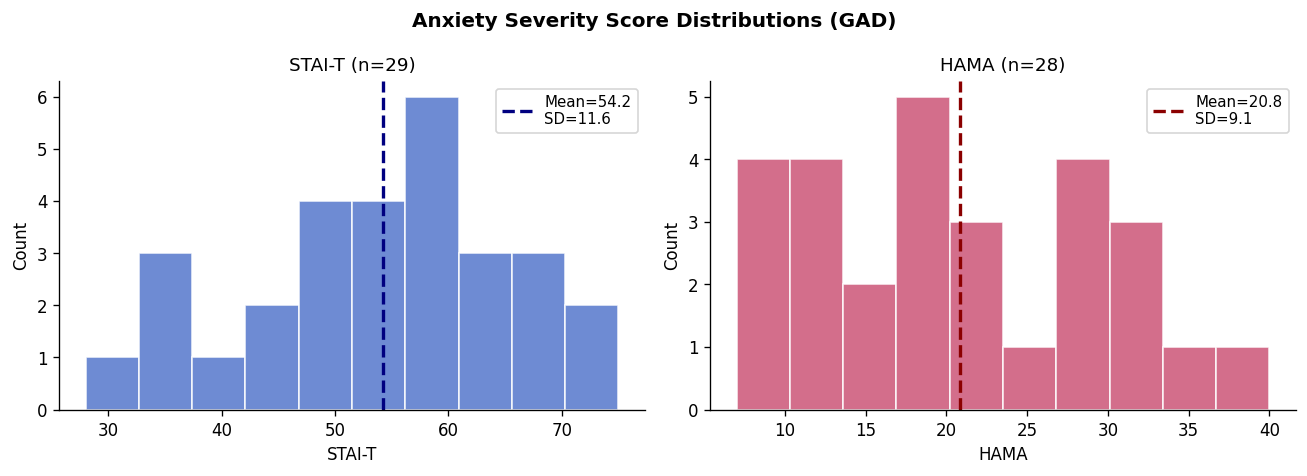

Saved: fig_severity_score_dist.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Anxiety Severity Score Distributions (GAD)', fontsize=12, fontweight='bold')

ax = axes[0]
ax.hist(stait_all, bins=10, color='#5577CC', edgecolor='white', alpha=0.85)
ax.axvline(stait_all.mean(), color='navy', lw=2, ls='--',
           label=f'Mean={stait_all.mean():.1f}\nSD={stait_all.std(ddof=1):.1f}')
ax.set_xlabel('STAI-T'); ax.set_ylabel('Count'); ax.set_title(f'STAI-T (n={len(stait_all)})')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(hama_vals, bins=10, color='#CC5577', edgecolor='white', alpha=0.85)
ax.axvline(hama_vals.mean(), color='darkred', lw=2, ls='--',
           label=f'Mean={hama_vals.mean():.1f}\nSD={hama_vals.std(ddof=1):.1f}')
ax.set_xlabel('HAMA'); ax.set_ylabel('Count'); ax.set_title(f'HAMA (n={len(hama_vals)})')
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_severity_score_dist.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_severity_score_dist.png')


## 6. Topographic Maps — Spearman r per Channel

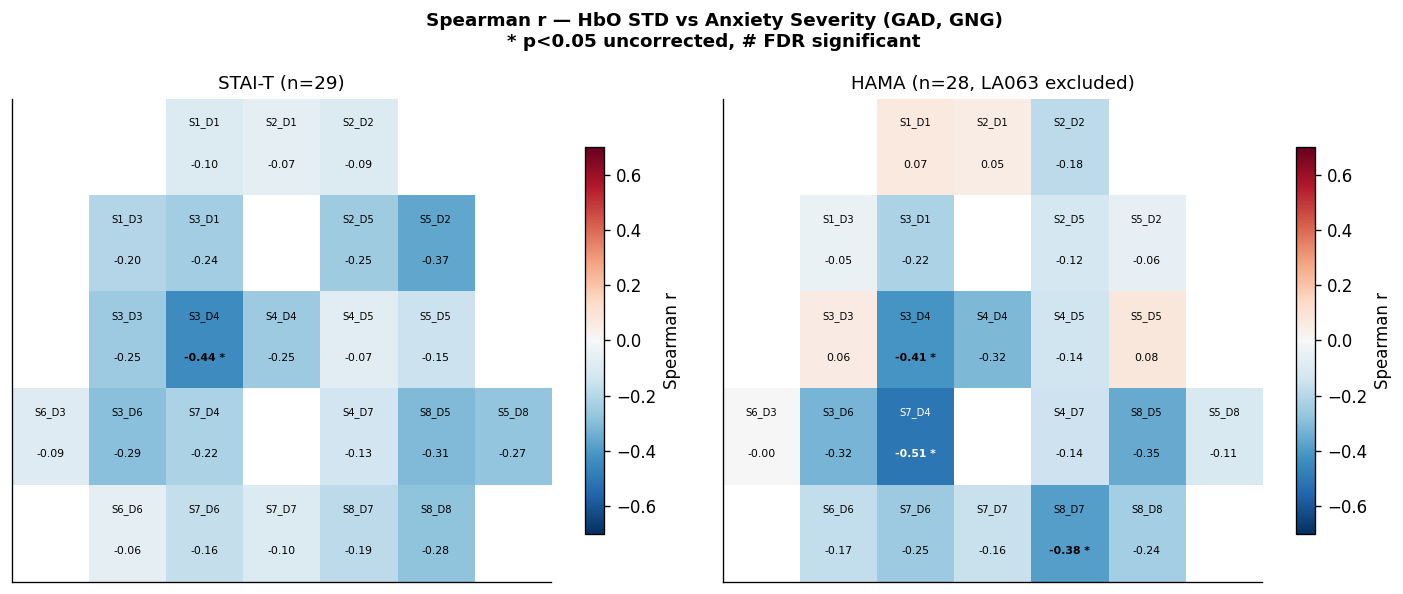

Saved: fig_stait_correlation_topo.png, fig_hama_correlation_topo.png


In [6]:
def plot_topo_r(ax, r_vals, p_vals, p_fdr, title, vmin=-0.7, vmax=0.7):
    grid = np.full(GRID_SHAPE, np.nan)
    for ch_i, (r_, c_) in enumerate(GRID_POS):
        grid[r_, c_] = r_vals[ch_i]
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    im = ax.imshow(grid, cmap='RdBu_r', norm=norm, aspect='auto')
    for ch_i, (r_, c_) in enumerate(GRID_POS):
        rv = r_vals[ch_i]; pv = p_vals[ch_i]; pfdr = p_fdr[ch_i]
        marker = ''
        if pfdr < 0.05: marker = ' #'
        elif pv < 0.05: marker = ' *'
        txt_color = 'white' if abs(rv) > 0.45 else 'black'
        ax.text(c_, r_-0.25, CHANNEL_NAMES[ch_i], ha='center', va='center',
                fontsize=6, color=txt_color)
        ax.text(c_, r_+0.18, f'{rv:.2f}{marker}', ha='center', va='center',
                fontsize=6.5, color=txt_color,
                fontweight='bold' if (pv < 0.05 or pfdr < 0.05) else 'normal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Spearman r — HbO STD vs Anxiety Severity (GAD, GNG)\n* p<0.05 uncorrected, # FDR significant',
             fontsize=11, fontweight='bold')
im1 = plot_topo_r(axes[0], results['STAIT']['r'], results['STAIT']['p'], results['STAIT']['p_fdr'],
                  f"STAI-T (n={results['STAIT']['n']})")
im2 = plot_topo_r(axes[1], results['HAMA']['r'],  results['HAMA']['p'],  results['HAMA']['p_fdr'],
                  f"HAMA (n={results['HAMA']['n']}, LA063 excluded)")
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='Spearman r')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Spearman r')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_stait_correlation_topo.png'), bbox_inches='tight', dpi=150)
fig.savefig(os.path.join(OUT_DIR, 'fig_hama_correlation_topo.png'),  bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_stait_correlation_topo.png, fig_hama_correlation_topo.png')


## 7. Top Channels — |r| Bar Chart and Scatter Plots

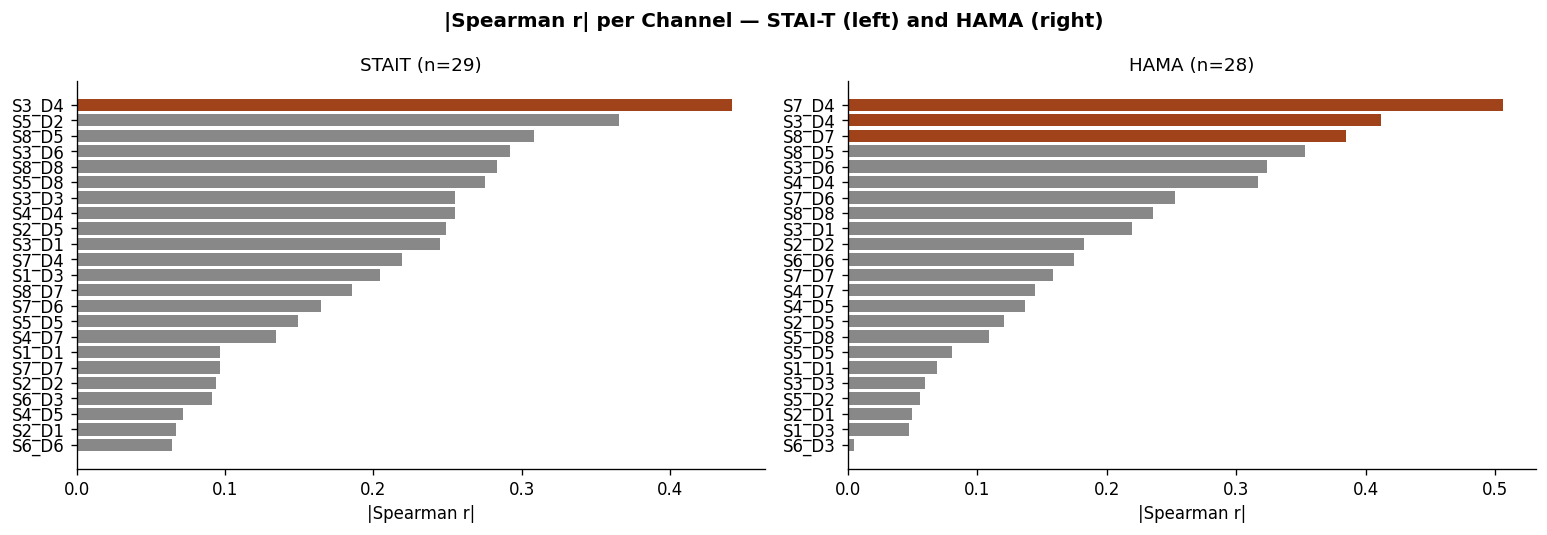

Saved: fig_severity_top_channels.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('|Spearman r| per Channel — STAI-T (left) and HAMA (right)', fontsize=12, fontweight='bold')
for ax, key in zip(axes, ['STAIT', 'HAMA']):
    r = results[key]['r']; p = results[key]['p']
    order = np.argsort(-np.abs(r))
    abs_r_sorted = np.abs(r)[order]
    ch_sorted = [CHANNEL_NAMES[i] for i in order]
    sig_mask = p[order] < 0.05
    ax.barh(ch_sorted, abs_r_sorted,
            color=['#A0421A' if s else '#888' for s in sig_mask])
    ax.invert_yaxis()
    ax.set_xlabel('|Spearman r|')
    ax.set_title(f'{key} (n={results[key]["n"]})')
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_severity_top_channels.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_severity_top_channels.png')


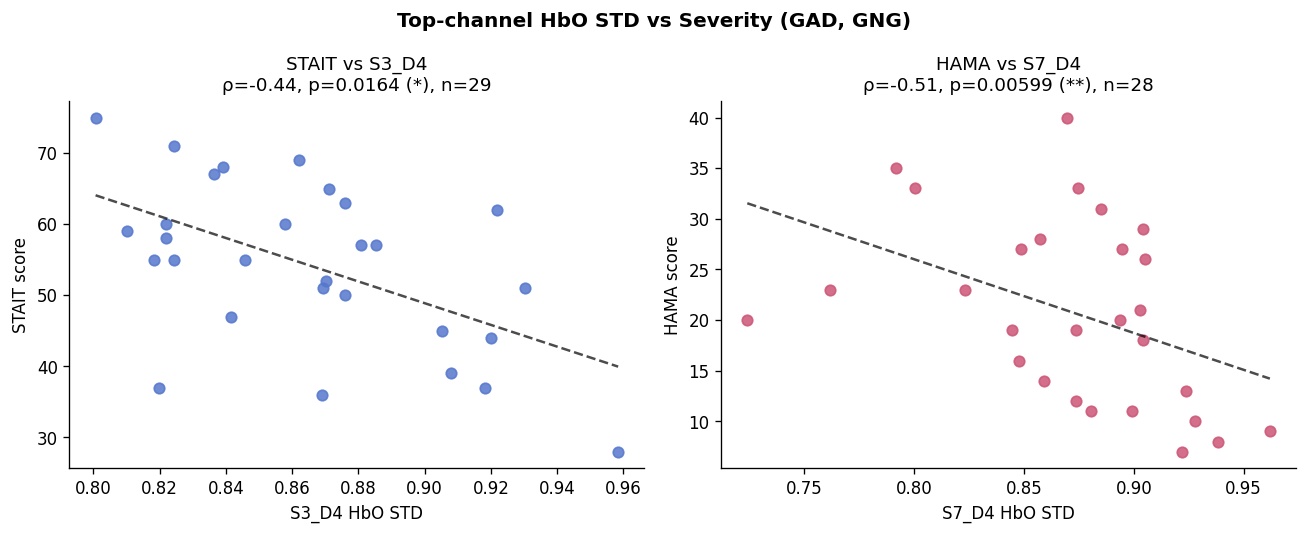

Saved: fig_s7d6_severity_scatter.png  (filename retained for parity with reference)


In [8]:
# Scatter for the strongest channel (by |r|) for each measure
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Top-channel HbO STD vs Severity (GAD, GNG)', fontsize=12, fontweight='bold')

for ax, key in zip(axes, ['STAIT', 'HAMA']):
    r = results[key]['r']
    top_idx = int(np.argmax(np.abs(r)))
    ch = CHANNEL_NAMES[top_idx]
    if key == 'STAIT':
        x = act[:, top_idx]; y = stait_all
    else:
        x = act[hama_mask, top_idx]; y = hama_vals
    ax.scatter(x, y, color='#5577CC' if key=='STAIT' else '#CC5577', s=40, alpha=0.85)
    # regression line
    slope, intercept, _, _, _ = stats.linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, slope*xs + intercept, 'k--', lw=1.5, alpha=0.7)
    rho, p_val = stats.spearmanr(x, y)
    ax.set_xlabel(f'{ch} HbO STD')
    ax.set_ylabel(f'{key} score')
    stars = '***' if p_val<0.001 else ('**' if p_val<0.01 else ('*' if p_val<0.05 else 'ns'))
    ax.set_title(f'{key} vs {ch}\nρ={rho:.2f}, p={p_val:.3g} ({stars}), n={len(x)}')

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_s7d6_severity_scatter.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_s7d6_severity_scatter.png  (filename retained for parity with reference)')


## 8. Summary & CSV Export

In [9]:
rows = []
for key in ['STAIT', 'HAMA']:
    for ch_i in range(N_CH):
        rows.append({
            'measure': key,
            'task'   : TASK,
            'channel': CHANNEL_NAMES[ch_i],
            'r'      : results[key]['r'][ch_i],
            'p_raw'  : results[key]['p'][ch_i],
            'p_fdr'  : results[key]['p_fdr'][ch_i],
            'sig_raw': results[key]['p'][ch_i] < 0.05,
            'sig_fdr': results[key]['p_fdr'][ch_i] < 0.05,
            'n'      : results[key]['n'],
        })
out_df = pd.DataFrame(rows)
out_csv = os.path.join(OUT_DIR, 'results_severity_correlation.csv')
out_df.to_csv(out_csv, index=False, float_format='%.6f')
print(f'Saved: {out_csv}  (rows={len(out_df)})')

print()
print('=' * 70)
print('  SEVERITY CORRELATION SUMMARY (GAD, GNG)')
print('=' * 70)
print(f'Method : Spearman rank correlation per channel + Benjamini-Hochberg FDR')
print(f'Cohort : GAD n={len(GAD_IDS)}  (HAMA uses 28 — LA063 excluded)')
print()
for key in ['STAIT', 'HAMA']:
    n_sig = (out_df[(out_df["measure"]==key) & out_df["sig_raw"]]).shape[0]
    n_fdr = (out_df[(out_df["measure"]==key) & out_df["sig_fdr"]]).shape[0]
    sig_chs = out_df[(out_df["measure"]==key) & out_df["sig_raw"]].sort_values('p_raw')['channel'].tolist()
    print(f'  {key:6s}: sig (uncorrected) = {n_sig}/{N_CH}, FDR = {n_fdr}/{N_CH}')
    if sig_chs:
        print(f'           → channels: {sig_chs}')
print()
print('Generated figures:')
for f in ['fig_severity_score_dist.png',
          'fig_stait_correlation_topo.png',
          'fig_hama_correlation_topo.png',
          'fig_severity_top_channels.png',
          'fig_s7d6_severity_scatter.png']:
    print(f'  - {f}')


Saved: /home/user/jeffrymahbuubi/PROJECTS/2-fNIRS-Graph-Base-Method/src/notebook/statistical-analysis/04_severity_correlation/results_severity_correlation.csv  (rows=46)

  SEVERITY CORRELATION SUMMARY (GAD, GNG)
Method : Spearman rank correlation per channel + Benjamini-Hochberg FDR
Cohort : GAD n=29  (HAMA uses 28 — LA063 excluded)

  STAIT : sig (uncorrected) = 1/23, FDR = 0/23
           → channels: ['S3_D4']
  HAMA  : sig (uncorrected) = 3/23, FDR = 0/23
           → channels: ['S7_D4', 'S3_D4', 'S8_D7']

Generated figures:
  - fig_severity_score_dist.png
  - fig_stait_correlation_topo.png
  - fig_hama_correlation_topo.png
  - fig_severity_top_channels.png
  - fig_s7d6_severity_scatter.png
